In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv(
    "../data/german.data-numeric",
    sep=r"\s+",
    header=None
)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [4]:
df.shape

(1000, 25)

reanaming columns for readability

In [5]:
df.columns = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "extra1",
    "extra2",
    "extra3",
    "extra4",
    "risk"
]

In [6]:
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,existing_credits,job,people_liable,telephone,foreign_worker,extra1,extra2,extra3,extra4,risk
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   checking_account   1000 non-null   int64
 1   duration           1000 non-null   int64
 2   credit_history     1000 non-null   int64
 3   purpose            1000 non-null   int64
 4   credit_amount      1000 non-null   int64
 5   savings            1000 non-null   int64
 6   employment         1000 non-null   int64
 7   installment_rate   1000 non-null   int64
 8   personal_status    1000 non-null   int64
 9   other_debtors      1000 non-null   int64
 10  residence_since    1000 non-null   int64
 11  property           1000 non-null   int64
 12  age                1000 non-null   int64
 13  installment_plans  1000 non-null   int64
 14  housing            1000 non-null   int64
 15  existing_credits   1000 non-null   int64
 16  job                1000 non-null   int64
 17  people_liable      1000 no

Data Documentation gives: 1 = Good credit
2 = Bad credit; need to convert this to: 0 = Low Risk
1 = High Risk

In [8]:
df["risk"] = np.where(df["risk"] == 2, 1, 0)
df["risk"].value_counts()

risk
0    700
1    300
Name: count, dtype: int64

results given: 700 Low Risk - 300 High Risk

Starting the Preprocessing part of the data

In [9]:
df = df.drop_duplicates()
df.shape

(1000, 25)

Define Features and Labels

In [12]:
X = df.drop("risk", axis=1)
y = df["risk"]

Train/Test Split

800 rows → training
200 rows → testing

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(max_iter=1000)

model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

Evaluate the Models

In [16]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.78
Random Forest Accuracy: 0.77


Confusion Matrix

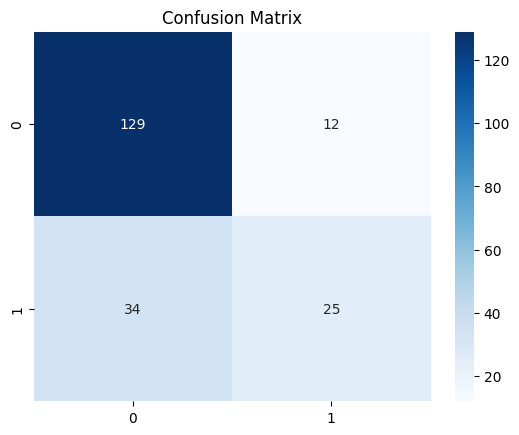

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Model Comparison

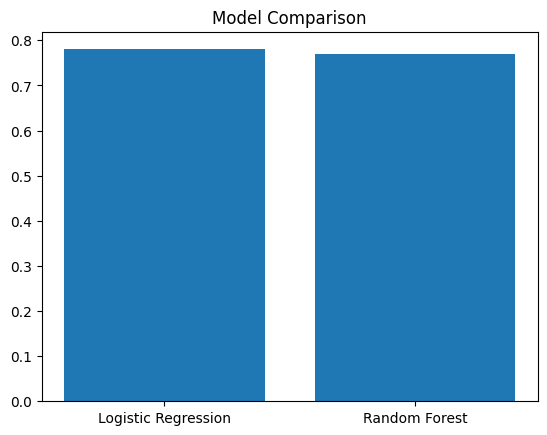

In [18]:
models = ["Logistic Regression", "Random Forest"]

scores = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()

Bonus:

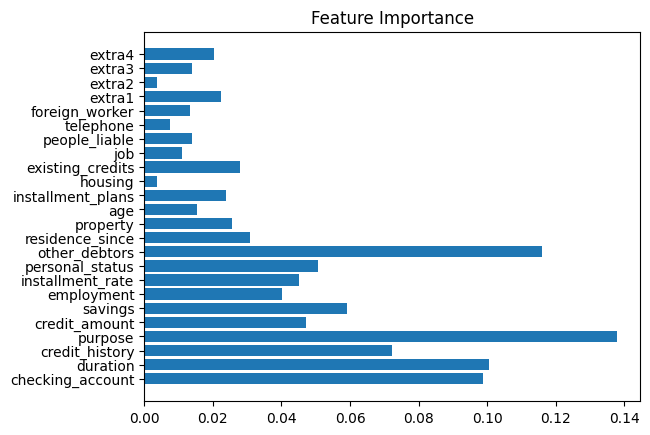

In [19]:
importances = model_rf.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()